Polynomial regression is a type of regression analysis used to model the relationship between a dependent variable and one or more independent variables by fitting a polynomial equation to the data. It is an extension of linear regression, which assumes a linear relationship between the variables.

### Core Concepts of Polynomial Regression:

1. **Polynomial Equation**: In polynomial regression, the relationship between the independent variable \( x \) and the dependent variable \( y \) is expressed as:
   \[
   y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \ldots + \beta_n x^n + \epsilon
   \]
   where \( \beta_0, \beta_1, \ldots, \beta_n \) are the coefficients to be estimated, \( n \) is the degree of the polynomial, and \( \epsilon \) is the error term.

2. **Degree of the Polynomial**: The degree \( n \) of the polynomial determines the complexity of the model. A linear regression is a polynomial regression of degree 1, while a quadratic regression is of degree 2, and so on. Higher-degree polynomials can fit more complex relationships but may also lead to overfitting.

3. **Fitting the Model**: The coefficients of the polynomial are typically estimated using the method of least squares, which minimizes the sum of the squared differences between the observed values and the values predicted by the polynomial model.

4. **Overfitting and Underfitting**: While polynomial regression can capture non-linear relationships, using a very high degree polynomial can lead to overfitting, where the model fits the noise in the data rather than the underlying trend. Conversely, a low-degree polynomial may underfit the data, failing to capture important patterns.

5. **Applications**: Polynomial regression is useful in various fields, including economics, biology, and engineering, where relationships between variables are not strictly linear.

6. **Visualization**: Polynomial regression can be visualized by plotting the data points and the fitted polynomial curve, which can help in understanding how well the model captures the underlying relationship.

In summary, polynomial regression is a flexible modeling technique that allows for the representation of non-linear relationships between variables through polynomial equations, but it requires careful consideration of the degree of the polynomial to avoid overfitting or underfitting the data.

### Differences
When comparing polynomial regression to linear regression, several key aspects can be considered, including model complexity, flexibility, performance, interpretability, and risk of overfitting. Here’s a detailed comparison:

### 1. **Model Complexity**
- **Linear Regression**: Models the relationship between the dependent variable and independent variable(s) as a straight line. The equation is of the form \( y = \beta_0 + \beta_1 x \).
- **Polynomial Regression**: Models the relationship using a polynomial equation, which can take various forms depending on the degree of the polynomial (e.g., quadratic, cubic). The equation is of the form \( y = \beta_0 + \beta_1 x + \beta_2 x^2 + \ldots + \beta_n x^n \).

### 2. **Flexibility**
- **Linear Regression**: Limited to capturing linear relationships. It may not perform well if the true relationship is non-linear.
- **Polynomial Regression**: More flexible and can capture non-linear relationships by adjusting the degree of the polynomial. Higher-degree polynomials can fit more complex patterns in the data.

### 3. **Performance**
- **Linear Regression**: Generally performs well when the relationship between variables is indeed linear. It is computationally efficient and requires fewer data points to estimate parameters.
- **Polynomial Regression**: Can outperform linear regression in cases where the relationship is non-linear. However, performance can degrade with very high-degree polynomials due to overfitting, where the model captures noise rather than the underlying trend.

### 4. **Interpretability**
- **Linear Regression**: Easier to interpret, as the coefficients represent the change in the dependent variable for a one-unit change in the independent variable. The relationship is straightforward.
- **Polynomial Regression**: More complex to interpret, especially with higher-degree polynomials. The coefficients of polynomial terms do not have a simple interpretation, and the relationship can be more difficult to visualize.

### 5. **Risk of Overfitting**
- **Linear Regression**: Lower risk of overfitting, especially with a small dataset, as it has fewer parameters.
- **Polynomial Regression**: Higher risk of overfitting, particularly with high-degree polynomials. The model may fit the training data very well but perform poorly on unseen data (test data).

### 6. **Use Cases**
- **Linear Regression**: Suitable for problems where the relationship is expected to be linear, such as predicting sales based on advertising spend.
- **Polynomial Regression**: Useful in scenarios where the relationship is known to be non-linear, such as modeling growth rates, trajectories, or certain biological processes.

### 7. **Visualization**
- **Linear Regression**: The fitted line is straightforward to visualize on a scatter plot.
- **Polynomial Regression**: The fitted curve can be visualized, showing how well it captures the data's trends, but it may have multiple bends and turns, especially with higher degrees.

### Summary
In summary, the choice between linear and polynomial regression depends on the nature of the data and the underlying relationship between the variables. Linear regression is simpler and more interpretable, while polynomial regression offers greater flexibility to model complex relationships but comes with increased risk of overfitting and reduced interpretability. It is essential to evaluate the model's performance using techniques like cross-validation to ensure that it generalizes well to new data.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [ ]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2

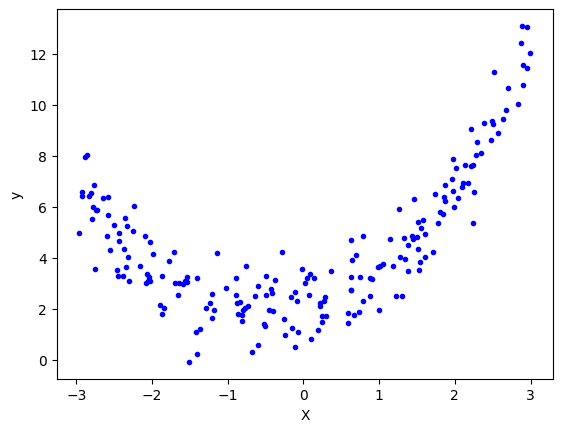

In [ ]:
plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [ ]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
# Applying linear regression
lr = LinearRegression()

In [ ]:
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.21602277827493221

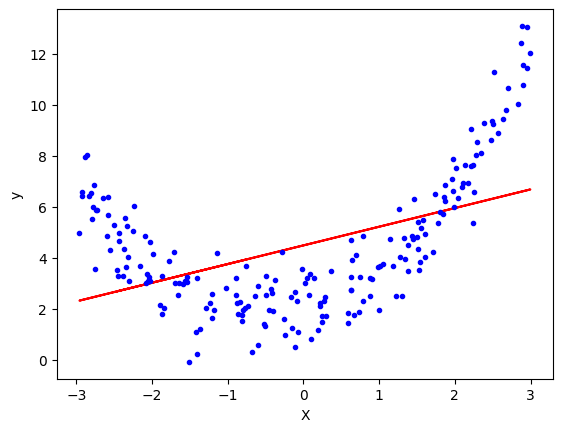

In [ ]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [ ]:
# Applying Polynomial Linear Regression
# degree 2
poly = PolynomialFeatures(degree=2,include_bias=True) # include_bias parameter

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [ ]:
print(X_train[0])
print(X_train_trans[0])

[-0.7571016]
[ 1.         -0.7571016   0.57320284]


In [ ]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test_trans)

In [ ]:
r2_score(y_test,y_pred)

0.9074465955220392

In [ ]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.82244713 0.82126413]]
[1.94373382]


In [ ]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)


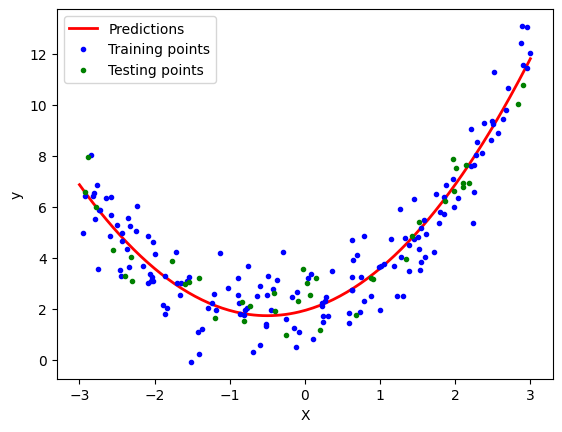

In [ ]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

In [ ]:
polynomial_regression(350)


ValueError: X has 1 features, but PolynomialFeatures is expecting 2 features as input.

In [ ]:
poly.powers_


array([[0],
       [1],
       [2]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


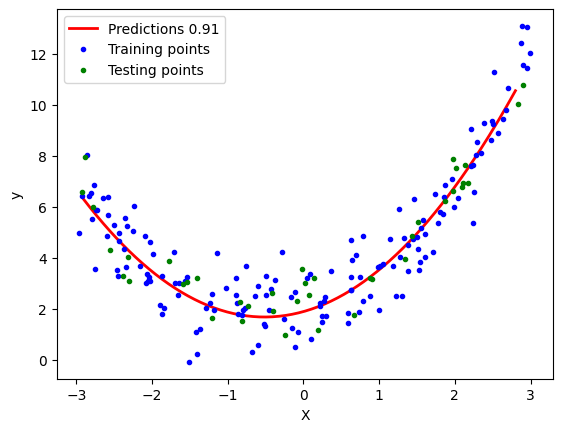

In [ ]:
# Applying Gradient Descent

poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(X_train_trans,y_train)

X_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = sgd.predict(X_new_poly)

y_pred = sgd.predict(X_test_trans)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [ ]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [ ]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [ ]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [ ]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [ ]:
poly = PolynomialFeatures(degree=30)
X_multi_trans = poly.fit_transform(X_multi)

In [ ]:
print("Input",poly.n_input_features_)
print("Ouput",poly.n_output_features_)
print("Powers\n",poly.powers_)

AttributeError: 'PolynomialFeatures' object has no attribute 'n_input_features_'

In [ ]:
X_multi_trans.shape


(100, 496)

In [ ]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [ ]:
X_test_multi = poly.transform(final)


In [ ]:
z_final = lr.predict(X_multi_trans).reshape(10,10)


In [ ]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()

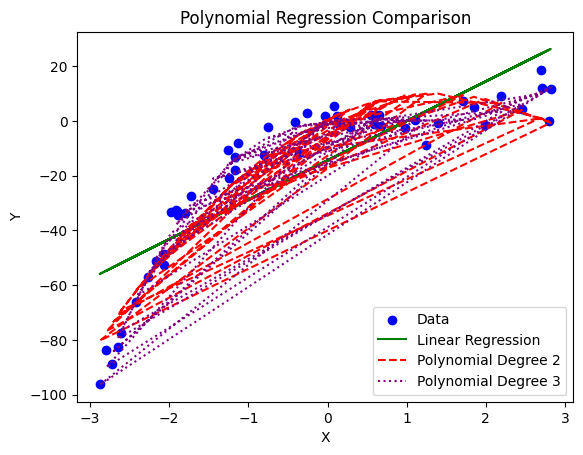

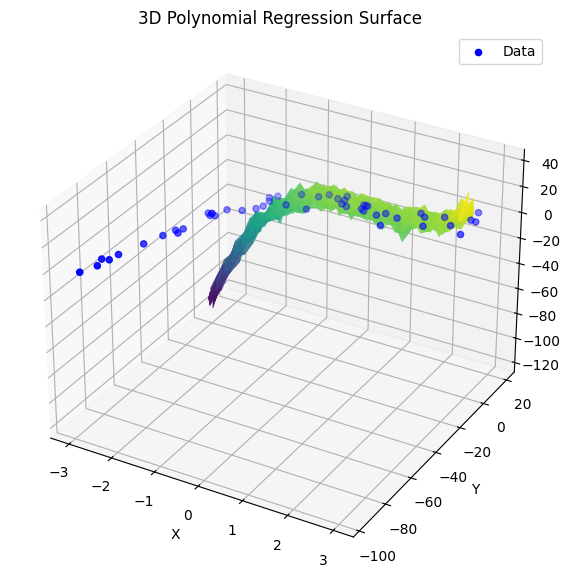

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from mpl_toolkits.mplot3d import Axes3D

# Generate synthetic data
np.random.seed(42)
x = np.random.uniform(-3, 3, 50)
y = 2*x**3 - 5*x**2 + 3*x + np.random.normal(0, 5, size=x.shape)  # Cubic Relationship

# Reshape x for sklearn
X = x.reshape(-1, 1)

# Linear Regression Model
linear_regressor = LinearRegression()
linear_regressor.fit(X, y)
y_pred_linear = linear_regressor.predict(X)

# Polynomial Regression Models (Degree 2 & 3)
poly_features_2 = PolynomialFeatures(degree=2)
X_poly_2 = poly_features_2.fit_transform(X)
poly_regressor_2 = LinearRegression()
poly_regressor_2.fit(X_poly_2, y)
y_pred_poly_2 = poly_regressor_2.predict(X_poly_2)

poly_features_3 = PolynomialFeatures(degree=3)
X_poly_3 = poly_features_3.fit_transform(X)
poly_regressor_3 = LinearRegression()
poly_regressor_3.fit(X_poly_3, y)
y_pred_poly_3 = poly_regressor_3.predict(X_poly_3)

# Visualization in 2D
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, y_pred_linear, color='green', label='Linear Regression')
plt.plot(x, y_pred_poly_2, color='red', linestyle='dashed', label='Polynomial Degree 2')
plt.plot(x, y_pred_poly_3, color='purple', linestyle='dotted', label='Polynomial Degree 3')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Polynomial Regression Comparison')
plt.show()

# 3D Visualization
X3D, Y3D = np.meshgrid(np.linspace(-3, 3, 30), np.linspace(-3, 3, 30))
Z3D = 2*X3D**3 - 5*X3D**2 + 3*X3D + np.random.normal(0, 5, X3D.shape)  # Same cubic pattern

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, np.zeros_like(x), color='blue', label='Data')
ax.plot_trisurf(X3D.flatten(), Y3D.flatten(), Z3D.flatten(), cmap='viridis', alpha=0.7)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Polynomial Regression Surface')
plt.legend()
plt.show()

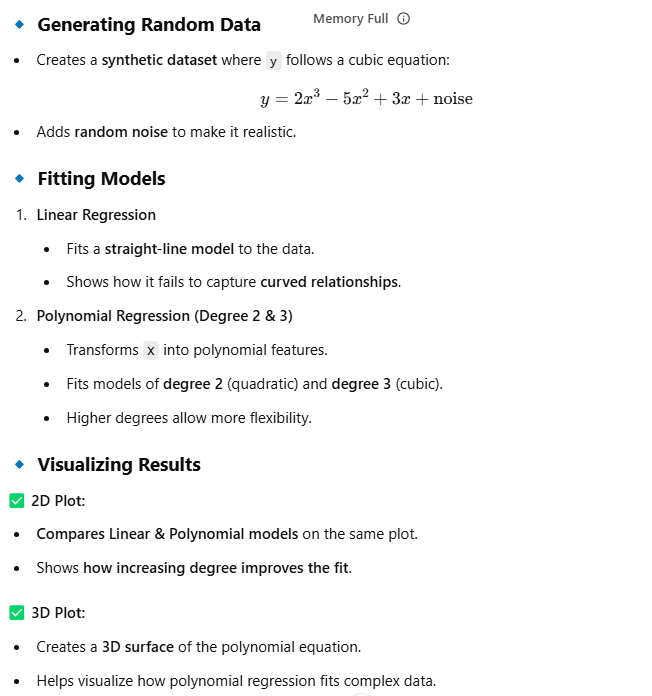

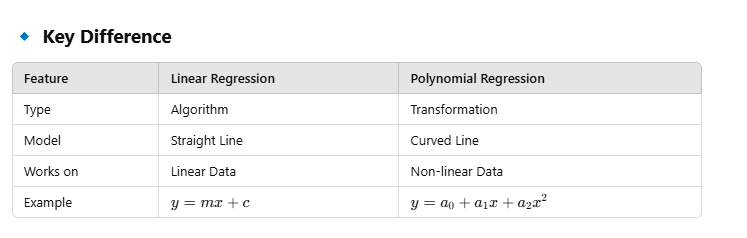